# Sonification sismique — 3 couches sémantiques

Ce notebook sépare le signal sismique en **3 couches** selon la fréquence,
puis donne une voix musicale différente à chacune :


## Étape 1 — Chargement des packages

In [38]:
using Pkg

cd(@__DIR__)
Pkg.activate("../")

using Dates
using SonifSismo
using Statistics
using WAV
using Seis
using CairoMakie
using DSP
using TuningSystems

push!(LOAD_PATH, "C:\\Users\\ameli\\Desktop\\Stage\\sonifSismo.jl\\TuningSystems.jl-main\\TuningSystems.jl-main\\src")
include("C:/Users/ameli/Desktop/Stage/sonifSismo.jl/examples/sonify_one_trace.jl")

println("✓ sonify_trace chargé ? ", isdefined(Main, :sonify_trace))
println("✓ write_sonification chargé ? ", isdefined(Main, :write_sonification))

✓ sonify_trace chargé ? 

  Activating project at `c:\Users\ameli\Desktop\Stage\sonifSismo.jl`


true
✓ write_sonification chargé ? true


## Étape 2 — Constantes globales

**Ce qu'il faut modifier ici :**
- `AUDIO_OUTPUT` => le dossier où seront sauvegardés tes fichiers audio
- `AUDIO_RATE` => laisse à 44100 (standard CD, ne pas changer)

In [39]:
const AUDIO_RATE = 44_100   #Fréquence d'échantillonnage audio (celle d'un CD normale)

#Dossier de sortie des fichiers audio (tous les audios seront enregistrés dans le dossier choisi ici)
const AUDIO_OUTPUT = joinpath("C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\08Juin\\test1_wU")
mkpath(AUDIO_OUTPUT)   #Crée le dossier s'il n'existe pas (donc pas besoin de créer le dossier avant)

"C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\08Juin\\test1_wU"

## Étape 3 — Chargement des données sismiques

Identique au notebook principal.
À la fin de cette étape, `trace_wU` contient le signal sismique brut.

In [40]:
# Chemin vers le dossier de données sismiques
archive = DataArchive("C:/Users/ameli/Desktop/Stage/mtFujiContinuous")

println("Stations disponibles : ", join(available_stations(archive), ", "))

Stations disponibles : FJO, FJO1, FJZ, FUJ, HSO, MMS, MMS2, MTS, MTS2, OIS, SBSR


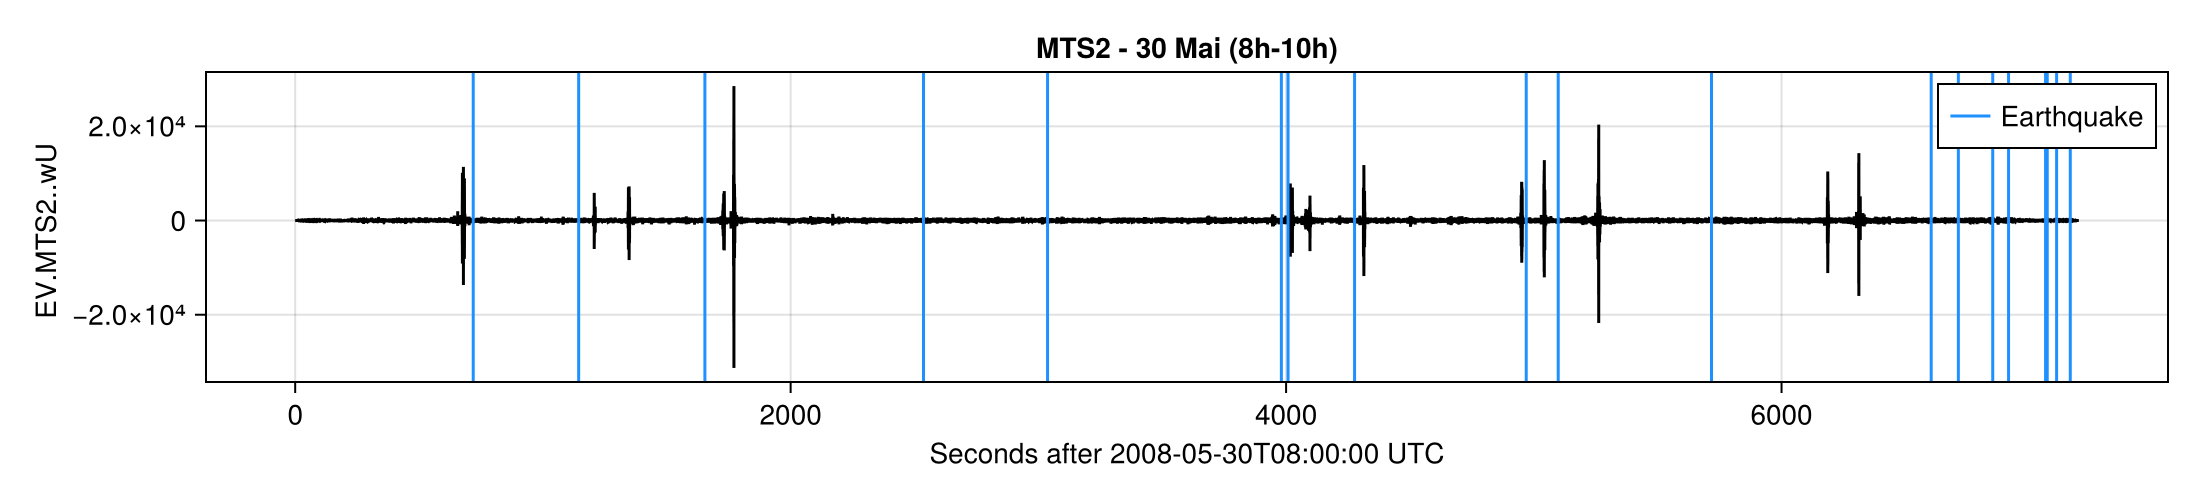

In [41]:
#Plot des données sismiques pour avoir une vision globale. 

t0_utc = DateTime(2008, 5, 30, 8, 0, 0)
t1_utc = DateTime(2008, 5, 30, 10, 0, 0)

traces = read_window(
    archive,
    t0_utc,
    t1_utc;
    stations  = "MTS2",                    
    channels  = ["wU"],
    merge     = true,
    processed = true,
    bandpass  = (0.5, 15),                  
)

plot_events = read_catalog(archive; start=t0_utc, stop=t1_utc)

wavefig = plot_waveforms(
    traces; events=plot_events,title="MTS2 - 30 Mai (8h-10h)"
)
save(joinpath(AUDIO_OUTPUT, "00_sis.png"), wavefig)

wavefig

In [42]:
trace_wU = only(t for t in traces if strip(t.sta.cha) == "wU")

Seis.Trace{Float64,Vector{Float32},Seis.Geographic{Float64}}:
            b: 28800.0
        delta: 0.01
 GeogStation{Float64}:
      sta.net: EV
      sta.sta: MTS2
      sta.loc: 
      sta.cha: wU 
     sta.meta: Seis.SeisDict{Symbol, Any}()
 GeogEvent{Float64}:
     evt.time: 2008-05-30T00:00:00
     evt.meta: Seis.SeisDict{Symbol, Any}()
 Trace:
        picks: 0
         meta: mseed_file => "C:\\Users\\ameli\\Desktop\\Stage\\mtFujiContinuous\\mseed\\2008\\05\\30\\EV.MTS2..wU.20080530.mseed"

## Étape 4 — Paramètres de la sonification 3 couches

**C'est ici que l'on modifie la plupart des paramètres**

### L'octave
Décale la hauteur musicale de chaque couche :
- `0` = hauteur naturelle du signal
- `+1` = une octave plus haut (× 2 en fréquence)
- `-2` = deux octaves plus bas (÷ 4 en fréquence)

### Le timbre (`harmonics`)
Tuple `(harmoniques_paires, harmoniques_impaires)` entre 0.0 et 0.6 :
- `(0.0, 0.0)` = son pur (sinusoïde)
- `(0.4, 0.0)` = son chaud, rond (comme un violoncelle)
- `(0.0, 0.5)` = son brillant, mordant (comme une guitare)

### La saturation
- `:none` = pas de saturation (son propre)
- `:soft` = saturation douce, son chaud / jazz
- `:hard` = saturation brutale, son électronique / rock


In [43]:
acceleration = 200

#Fréquences de coupure 
FREQ_BG_MAX  = 1.0
FREQ_LFE_MIN = 1.0
FREQ_LFE_MAX = 5.0
FREQ_EQ_MIN  = 5.0
FREQ_EQ_MAX  = 15.0

#Timbre par couche
OCTAVE_BG    = -1          
HARM_BG      = (0.2, 0.1)  
GAIN_BG      = 1
SAT_BG       = :soft

OCTAVE_LFE   = 0          
HARM_LFE     = (0.15, 0.15)  
GAIN_LFE     = 3
SAT_LFE      = :soft

OCTAVE_EQ    = 1           
HARM_EQ      = (0.05, 0.3)  
GAIN_EQ      = 4
SAT_EQ       = :soft       

#Volumes
LEVEL_BG  = 0.1   
LEVEL_LFE = 0.4   
LEVEL_EQ  = 0.70   

#Gamme et accords
my_tuning = just

root_hz   = 130.81   # Do3

CHORD_BG  = "G D"         
CHORD_LFE = "G B D"       
CHORD_EQ  = "B D G"       

NOTE_DURATION_EQ = 1
BPM = 100   

println("Paramètres musicaux chargés")

Paramètres musicaux chargés


In [44]:
#Juste pour voir quelle durée aura l'audio final

duree_sismique_s = length(Seis.trace(trace_wU)) * trace_wU.delta
duree_audio_s    = duree_sismique_s / acceleration

println("Durée sismique  : ", round(duree_sismique_s / 3600; digits=2), " heures")
println("Durée audio     : ", round(duree_audio_s / 60; digits=2), " min")

Durée sismique  : 2.0 heures
Durée audio     : 0.6 min


## Étape 5 — Filtrage du signal en 3 bandes

On extrait le signal brut de la trace, puis on applique 3 filtres :
- `Lowpass` => ne laisse passer que les fréquences **en dessous** du seuil
- `Bandpass` => ne laisse passer que les fréquences **entre** deux seuils
- `Butterworth(4)` => type de filtre, ordre 4 (bonne netteté sans artefacts)
- `filtfilt` => applique le filtre aller+retour pour éviter le décalage temporel

In [45]:
fs  = inv(trace_wU.delta)            #fréquence d'échantillonnage sismique (Hz)
raw = Float64.(Seis.trace(trace_wU)) #signal brut sous forme de tableau Float64

#Filtre 1 : bruit de fond
filt_bg  = digitalfilter(Lowpass(FREQ_BG_MAX; fs=fs), Butterworth(4))
sig_bg   = filtfilt(filt_bg, raw)    

#Filtre 2 : LFE
filt_lfe = digitalfilter(Bandpass(FREQ_LFE_MIN, FREQ_LFE_MAX; fs=fs), Butterworth(4))
sig_lfe  = filtfilt(filt_lfe, raw)

#Filtre 3 : EQ
filt_eq  = digitalfilter(Bandpass(FREQ_EQ_MIN, FREQ_EQ_MAX; fs=fs), Butterworth(4))
sig_eq   = filtfilt(filt_eq, raw)

720001-element Vector{Float64}:
  1.5452058529319206e-5
  1.0942551088334735e-5
  7.4449898865368425e-6
  5.323898029548109e-6
  1.784868406028737e-6
 -6.78285704135704e-6
 -2.12349175450949e-5
 -3.7710327282453244e-5
 -4.9119421456165264e-5
 -4.9374368710091435e-5
  ⋮
  2.6311093714304274e-5
  2.6043702271057467e-5
  2.319191645595325e-5
  1.683592016787281e-5
  7.613190751238268e-6
 -2.2273050603790286e-6
 -9.92934746089109e-6
 -1.3738241956536349e-5
 -1.3795234701819136e-5

## Étape 6 — Recréer des traces Seis pour chaque bande

`sonify_trace` a besoin d'un objet **trace Seis** (pas juste un tableau).
On copie la trace originale avec `deepcopy` — ça duplique tout l'objet en mémoire.
Puis on remplace uniquement les données du signal (`t.t`) par le signal filtré.
Tout le reste (delta, timestamps, métadonnées) reste identique.

C'est ce qui garantit que `sonify_trace` produira la **même durée** pour les 3 couches.

In [46]:
#Fonction utilitaire : copie une trace et remplace son signal

function make_trace(original_trace, new_signal)
    t = deepcopy(original_trace)      #copie complète (métadonnées incluses)
    t.t = Float32.(new_signal)        #remplace le signal (Float32 requis par Seis)
    return t
end

trace_bg  = make_trace(trace_wU, sig_bg)
trace_lfe = make_trace(trace_wU, sig_lfe)
trace_eq  = make_trace(trace_wU, sig_eq)

println("✓ 3 traces créées — longueurs : ",
    length(Seis.trace(trace_bg)), " / ",
    length(Seis.trace(trace_lfe)), " / ",
    length(Seis.trace(trace_eq)), " échantillons")

✓ 3 traces créées — longueurs : 720001 / 720001 / 720001 échantillons


## Étape 7 — Sonification de chaque couche

On utilise exactement `sonify_trace` comme dans le notebook principal.
La différence : `octave`, `harmonics` et `saturation` différents par couche
pour donner une **couleur sonore** distincte à chacune.

Les 3 durées audio affichées doivent être identiques — c'est une vérification.

In [47]:
#COUCHE 1 : Bruit de fond
sono_bg = sonify_trace(
    trace_bg;
    acceleration = acceleration,
    octave       = OCTAVE_BG,
    harmonics    = HARM_BG,
    gain         = GAIN_BG,
    saturation   = SAT_BG,
    level        = 0.90,
)

#Durée cible en samples audio
n_audio = length(sono_bg.signal) #c'est le tableau d'échantillons audio produit par sonify_trace => devient la référence de durée

t_audio = (0:n_audio-1) ./ AUDIO_RATE #tableau des instants en secondes. En divisant par AUDIO_RATE (44100), on convertit ces indices en secondes.
#Ce vecteur temps est indispensable pour calculer sin(2π × f × t) — sans lui on ne sait pas à quel instant de temps correspond chaque échantillon.

#Synthèse directe d'un accord par sinusoïdes
function synth_chord(freqs, t_vec)
    out = zeros(length(t_vec))
    for f in freqs
        out .+= sin.(2π .* f .* t_vec) #C'est la formule d'un son pur
    end
    out ./= length(freqs)
    return out #Retourne le tableau audio final — la somme de toutes les sinusoïdes normalisée.
end

#COUCHE 2 : LFE → fréquences de l'accord

lfe_tones = tns(CHORD_LFE; tuning=my_tuning, root_frequency=root_hz) #tns(...) est une fonction de TuningSystems :  
#Elle prend le nom des notes (CHORD_LFE = "C E G" par exemple) et calcule les fréquences exactes en Hz selon la gamme choisie

lfe_freqs = [t.frequency for t in lfe_tones] #Compréhension de liste : pour chaque objet t dans lfe_tones, extrait juste le champ .frequency. 
#On obtient un simple tableau de nombres en Hz

lfe_arr   = synth_chord(lfe_freqs, t_audio) #Appelle la fonction qu'on vient de définir avec les fréquences LFE et le vecteur temps. 
#Résultat : un tableau audio de la même durée que sono_bg, contenant l'accord LFE en sinusoïdes pures.

#Pour l'instant il est constant et c'est l'enveloppe qui lui donnera les variations.

#COUCHE 3 : EQ → fréquences de l'accord
eq_tones = tns(CHORD_EQ; tuning=my_tuning, root_frequency=root_hz * 2)
eq_freqs = [t.frequency for t in eq_tones]
eq_arr   = synth_chord(eq_freqs, t_audio)

3175204-element Vector{Float64}:
  0.0
  0.055879034530420056
  0.11156162830727438
  0.16685212065091135
  0.2215564076754197
  0.27548271231541893
  0.3284423443510763
  0.3802504471677506
  0.4307267280465237
  0.479696168856177
  ⋮
 -0.12409960211934057
 -0.1163214013524892
 -0.10726704644152175
 -0.09693684918466466
 -0.08533834724879986
 -0.07248638423864309
 -0.05840315292977461
 -0.0431182012544413
 -0.02666840068489706

Maintenant on va régler **l'enveloppe**. L'enveloppe c'est le volume instantané, elle s'obtient en prenant la valeur absolue du signal. 

L'enveloppe dit quand un phénomène est actif et à quelles intensités. Par exemple, elle sert à dire quand y a un LFE : quand l'enveloppe est haute = LFE alors on fait sonner l'accord LFE fort. 

In [48]:
#Fonction de lissage de l'enveloppe : 
#window_s = durée de la fenêtre de lissage en secondes
#Plus c'est grand, plus les transitions sont douces

function smooth_envelope(env, fs_audio; window_s=0.1)
    w = max(1, round(Int, window_s * fs_audio))   #taille de la fenêtre en samples
    kernel = ones(w) ./ w                          #filtre moyenneur
    return DSP.conv(env, kernel)[1:length(env)]    #convolution = lissage
end

#COUCHE 2 : LFE — enveloppe lissée
lfe_env   = abs.(sig_lfe)
lfe_env ./= (maximum(lfe_env) + 1e-9)
idx_lfe   = clamp.(round.(Int, range(1, length(lfe_env), length=n_audio)), 1, length(lfe_env))
lfe_env_resampled = lfe_env[idx_lfe]

lfe_env_smooth = smooth_envelope(lfe_env_resampled, AUDIO_RATE; window_s=0.8)
lfe_modulated  = lfe_arr .* lfe_env_smooth

#COUCHE 3 : EQ — enveloppe lissée
eq_env   = abs.(sig_eq)
eq_env ./= (maximum(eq_env) + 1e-9)
idx_eq   = clamp.(round.(Int, range(1, length(eq_env), length=n_audio)), 1, length(eq_env))
eq_env_resampled = eq_env[idx_eq]

eq_env_smooth  = smooth_envelope(eq_env_resampled, AUDIO_RATE; window_s=0.3)
eq_modulated   = eq_arr .* eq_env_smooth

3175204-element Vector{Float64}:
  0.0
  6.7056983424839774e-15
  2.008175875336951e-14
  3.712412146842415e-14
  5.870986359934816e-14
  8.47054114233009e-14
  1.1494526951777388e-13
  1.4406973478308922e-13
  1.756461979966372e-13
  2.0948349540784923e-13
  ⋮
 -2.4592381405093213e-6
 -2.3040948020410846e-6
 -2.12407201727783e-6
 -1.918907175575109e-6
 -1.6887734938198725e-6
 -1.433988531826744e-6
 -1.1552344943725322e-6
 -8.527841037472887e-7
 -5.273755994198853e-7

## Étape 8 — Export des couches séparées

Export des 3 couches séparéments.

In [49]:
wavwrite(Float32.(Float64.(sono_bg.signal)),
         joinpath(AUDIO_OUTPUT, "01_couche_bg.wav");
         Fs=AUDIO_RATE, nbits=16, compression=WAVE_FORMAT_PCM)

wavwrite(Float32.(lfe_modulated),
         joinpath(AUDIO_OUTPUT, "02_couche_lfe.wav");
         Fs=AUDIO_RATE, nbits=16, compression=WAVE_FORMAT_PCM)

wavwrite(Float32.(eq_modulated),
         joinpath(AUDIO_OUTPUT, "03_couche_eq.wav");
         Fs=AUDIO_RATE, nbits=16, compression=WAVE_FORMAT_PCM)

println("✓ Couches individuelles exportées dans : ", AUDIO_OUTPUT)

✓ Couches individuelles exportées dans : C:\Users\ameli\Desktop\Stage\Résultats\08Juin\test1_wU


## Étape 9 — Mixage des 3 couches

On additionne les 3 signaux avec des poids (`LEVEL_*`) définis à l'étape 4 :

```
mixage = LEVEL_BG × signal_BG + LEVEL_LFE × signal_LFE + LEVEL_EQ × signal_EQ
```

Ensuite on **normalise** : on divise tout par le pic maximum pour que le son
ne sature jamais (saturation = son coupé/distordu de façon laide).

In [50]:
bg_arr = Float64.(sono_bg.signal)

#Aligne les longueurs
n = minimum(length, [bg_arr, lfe_modulated, eq_modulated])

mixed = LEVEL_BG  .* bg_arr[1:n]        .+
        LEVEL_LFE .* lfe_modulated[1:n] .+
        LEVEL_EQ  .* eq_modulated[1:n]

#Normalise
peak = maximum(abs, mixed)
if peak > 0
    mixed .*= 0.90 / peak
end

wavwrite(
    Float32.(mixed),
    joinpath(AUDIO_OUTPUT, "04_mix_3couches_musical.wav");
    Fs=AUDIO_RATE, nbits=16, compression=WAVE_FORMAT_PCM
)
println("✓ 04_mix_3couches_musical.wav — durée : ",
        round(n/AUDIO_RATE; digits=1), " s")

✓ 04_mix_3couches_musical.wav — durée : 72.0 s


## Étape 10 — Visualisation des 3 bandes filtrées

Affiche les 3 signaux filtrés.

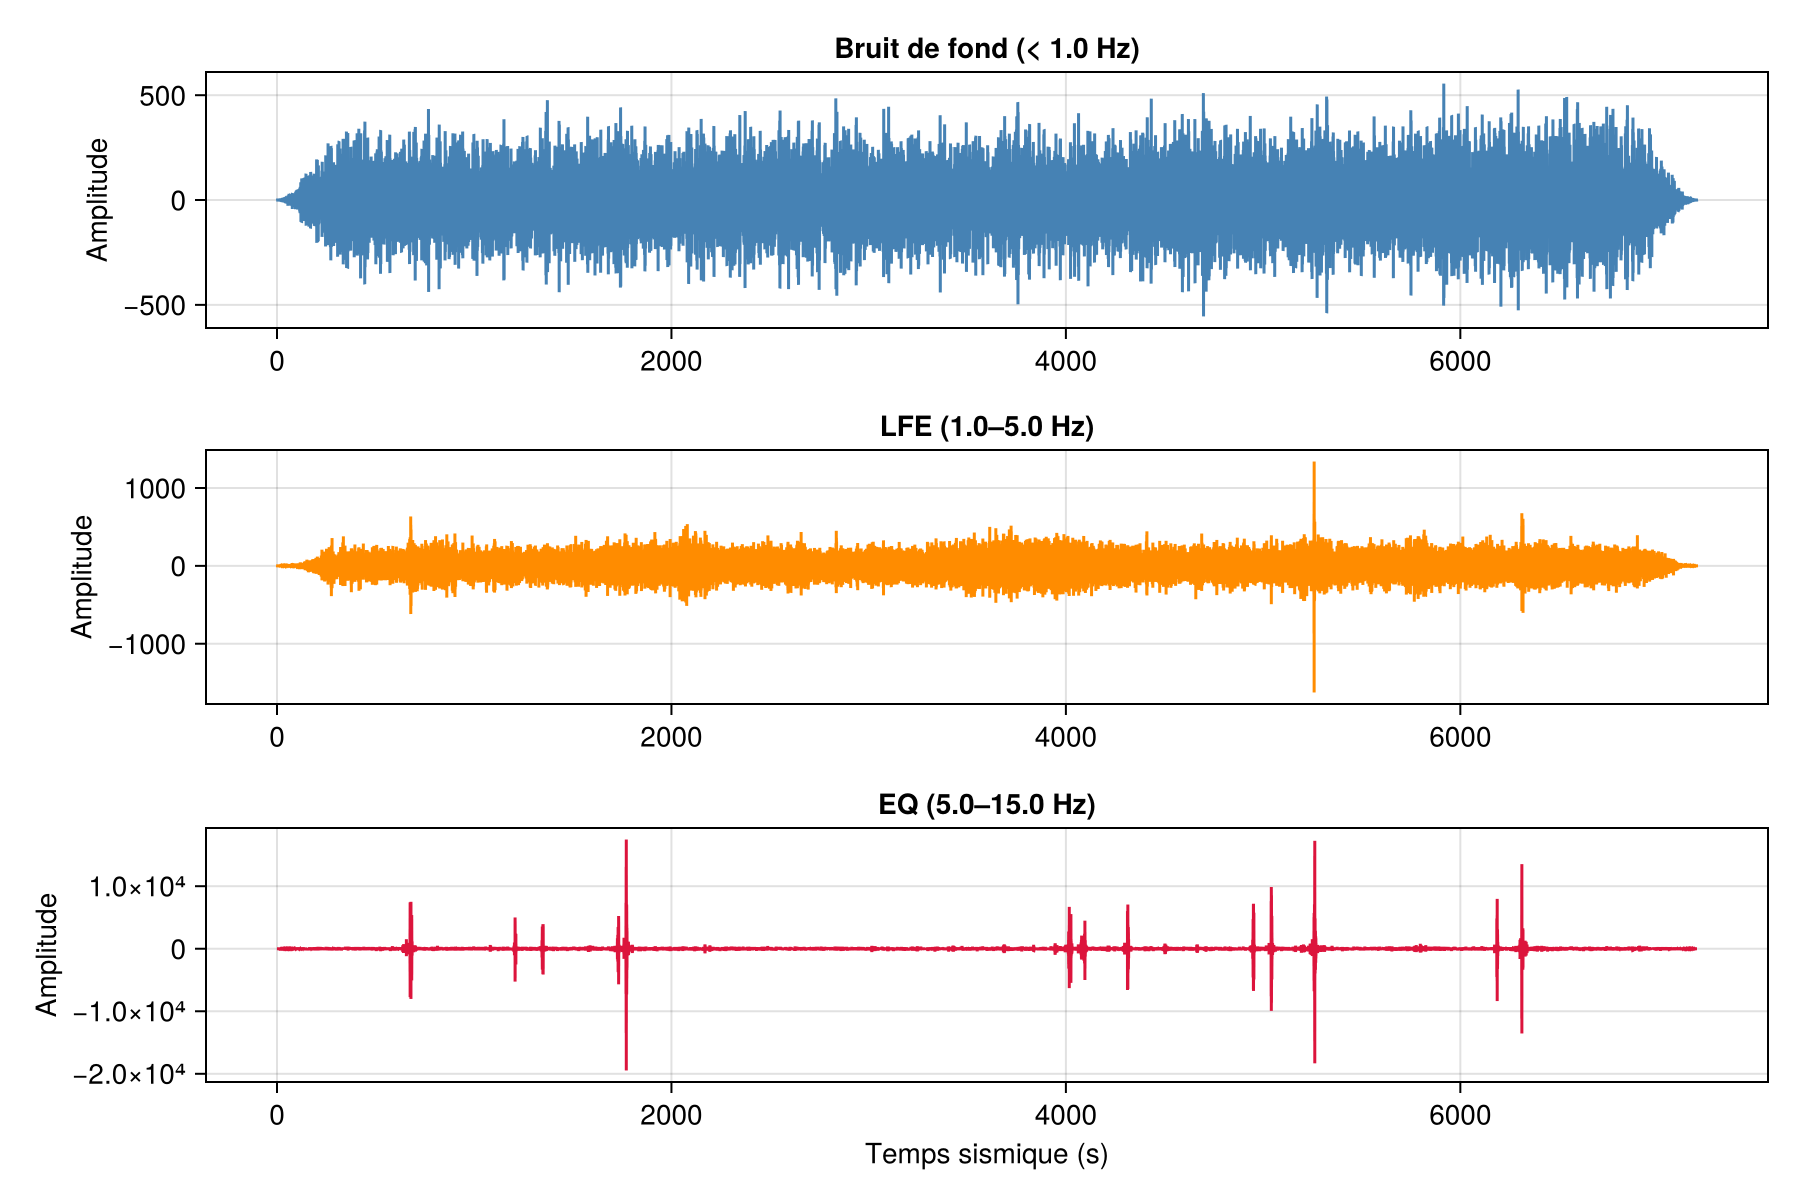

In [51]:
# Axe temps en secondes sismiques
t_sismo = (0:length(raw)-1) ./ fs

fig = Figure(size=(900, 600))

ax1 = Axis(fig[1, 1]; title="Bruit de fond (< $(FREQ_BG_MAX) Hz)",
           ylabel="Amplitude")
ax2 = Axis(fig[2, 1]; title="LFE ($(FREQ_LFE_MIN)–$(FREQ_LFE_MAX) Hz)",
           ylabel="Amplitude")
ax3 = Axis(fig[3, 1]; title="EQ ($(FREQ_EQ_MIN)–$(FREQ_EQ_MAX) Hz)",
           xlabel="Temps sismique (s)", ylabel="Amplitude")

lines!(ax1, t_sismo, sig_bg;  color=:steelblue)
lines!(ax2, t_sismo, sig_lfe; color=:darkorange)
lines!(ax3, t_sismo, sig_eq;  color=:crimson)

save(joinpath(AUDIO_OUTPUT, "05_bandes_filtrees.png"), fig)
fig

## Enregistre les paramètres choisis dans un fichier txt

Intéressant pour conserver les paramètres choisis sans avoir à les noter ? (Surtout quand on oublie de les noter ^^)

In [52]:
param_log = joinpath(AUDIO_OUTPUT, "parametres.txt")

lignes = [
    "═══════════════════════════════════════════════════",
    " PARAMÈTRES DE SONIFICATION — $(Dates.now())",
    "═══════════════════════════════════════════════════",
    "",
    "── DONNÉES SISMIQUES ───────────────────────────────",
    "Archive        : $(archive.root)",
    "Station        : $(trace_wU.sta.sta)",
    "Canal          : $(strip(trace_wU.sta.cha))",
    "Début (UTC)    : $(t0_utc)",
    "Fin   (UTC)    : $(t1_utc)",
    "Durée sismique : $(round(duree_sismique_s / 3600; digits=2)) heures",
    "Fréq. échant.  : $(inv(trace_wU.delta)) Hz",
    "",
    "── FILTRES ─────────────────────────────────────────",
    "Bruit de fond  : 0 – $(FREQ_BG_MAX) Hz",
    "LFE            : $(FREQ_LFE_MIN) – $(FREQ_LFE_MAX) Hz",
    "EQ             : $(FREQ_EQ_MIN) – $(FREQ_EQ_MAX) Hz",
    "",
    "── SONIFICATION ────────────────────────────────────",
    "Accélération   : $(acceleration)",
    "Durée audio    : $(round(n_audio/AUDIO_RATE; digits=1)) s",
    "",
    "── COUCHE BRUIT DE FOND ────────────────────────────",
    "Octave         : $(OCTAVE_BG)",
    "Harmoniques    : $(HARM_BG)",
    "Gain           : $(GAIN_BG)",
    "Saturation     : $(SAT_BG)",
    "Volume mixage  : $(LEVEL_BG)",
    "",
    "── COUCHE LFE ──────────────────────────────────────",
    "Octave         : $(OCTAVE_LFE)",
    "Harmoniques    : $(HARM_LFE)",
    "Gain           : $(GAIN_LFE)",
    "Saturation     : $(SAT_LFE)",
    "Volume mixage  : $(LEVEL_LFE)",
    "",
    "── COUCHE EQ ───────────────────────────────────────",
    "Octave         : $(OCTAVE_EQ)",
    "Harmoniques    : $(HARM_EQ)",
    "Gain           : $(GAIN_EQ)",
    "Saturation     : $(SAT_EQ)",
    "Volume mixage  : $(LEVEL_EQ)",
    "",
    "── PARAMÈTRES MUSICAUX ─────────────────────────────",
    "Gamme          : $(my_tuning)",
    "Fréquence root : $(root_hz) Hz",
    "Accord BG      : $(CHORD_BG)",
    "Accord LFE     : $(CHORD_LFE)",
    "Accord EQ      : $(CHORD_EQ)",
    "BPM            : $(BPM)",
    "",
    "── QUANTIFICATION ──────────────────────────────────",
    "Durée note LFE : 0.5 s (blanche)",
    "Seuil LFE      : 0.1",
    "Durée note EQ  : 0.25 s (noire)",
    "Seuil EQ       : 0.2",
    ""
]   


push!(lignes, "")
push!(lignes, "═══════════════════════════════════════════════════")

open(param_log, "w") do f
    for ligne in lignes
        write(f, ligne * "\r\n")
    end
end

println("✓ Paramètres sauvegardés dans : ", param_log)

✓ Paramètres sauvegardés dans : C:\Users\ameli\Desktop\Stage\Résultats\08Juin\test1_wU\parametres.txt


In [ ]:
param_log = joinpath(AUDIO_OUTPUT, "parametres.txt")

lignes = [
    "═══════════════════════════════════════════════════",
    " PARAMÈTRES DE SONIFICATION — $(Dates.now())",
    "═══════════════════════════════════════════════════",
    "",
    "── DONNÉES SISMIQUES ───────────────────────────────",
    "Archive        : $(archive.root)",
    "Station        : $(trace_wU.sta.sta)",
    "Canal          : $(strip(trace_wU.sta.cha))",
    "Début (UTC)    : $(t0_utc)",
    "Fin   (UTC)    : $(t1_utc)",
    "Durée sismique : $(round(duree_sismique_s / 3600; digits=2)) heures",
    "Fréq. échant.  : $(inv(trace_wU.delta)) Hz",
    "",
    "── FILTRES ─────────────────────────────────────────",
    "Bruit de fond  : 0 – $(FREQ_BG_MAX) Hz",
    "LFE            : $(FREQ_LFE_MIN) – $(FREQ_LFE_MAX) Hz",
    "EQ             : $(FREQ_EQ_MIN) – $(FREQ_EQ_MAX) Hz",
    "",
    "── SONIFICATION ────────────────────────────────────",
    "Accélération   : $(acceleration)",
    "Durée audio    : $(round(n_audio/AUDIO_RATE; digits=1)) s",
    "",
    "── COUCHE BRUIT DE FOND ────────────────────────────",
    "Octave         : $(OCTAVE_BG)",
    "Harmoniques    : $(HARM_BG)",
    "Gain           : $(GAIN_BG)",
    "Saturation     : $(SAT_BG)",
    "Volume mixage  : $(LEVEL_BG)",
    "",
    "── COUCHE LFE ──────────────────────────────────────",
    "Octave         : $(OCTAVE_LFE)",
    "Harmoniques    : $(HARM_LFE)",
    "Gain           : $(GAIN_LFE)",
    "Saturation     : $(SAT_LFE)",
    "Volume mixage  : $(LEVEL_LFE)",
    "",
    "── COUCHE EQ ───────────────────────────────────────",
    "Octave         : $(OCTAVE_EQ)",
    "Harmoniques    : $(HARM_EQ)",
    "Gain           : $(GAIN_EQ)",
    "Saturation     : $(SAT_EQ)",
    "Volume mixage  : $(LEVEL_EQ)",
    "",
    "── PARAMÈTRES MUSICAUX ─────────────────────────────",
    "Gamme          : $(my_tuning)",
    "Fréquence root : $(root_hz) Hz",
    "Accord BG      : $(CHORD_BG)",
    "Accord LFE     : $(CHORD_LFE)",
    "Accord EQ      : $(CHORD_EQ)",
    "BPM            : $(BPM)",
    "",
    "── QUANTIFICATION ──────────────────────────────────",
    "Durée note LFE : 0.5 s (blanche)",
    "Seuil LFE      : 0.1",
    "Durée note EQ  : 0.25 s (noire)",
    "Seuil EQ       : 0.2",
    ""
]   


push!(lignes, "")
push!(lignes, "═══════════════════════════════════════════════════")

open(param_log, "w") do f
    for ligne in lignes
        write(f, ligne * "\r\n")
    end
end

println("✓ Paramètres sauvegardés dans : ", param_log)

✓ Paramètres sauvegardés dans : C:\Users\ameli\Desktop\Stage\Résultats\08Juin\test1_wU\parametres.txt


Pour additionner les trois composantes : 

In [55]:
using WAV

# Lecture des fichiers
xN, fsN = wavread("C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\08Juin\\test1_wN\\04_mix_3couches_musical.wav")
xU, fsU = wavread("C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\08Juin\\test1_wU\\04_mix_3couches_musical.wav")
xE, fsE = wavread("C:\\Users\\ameli\\Desktop\\Stage\\Résultats\\08Juin\\test1_wE\\04_mix_3couches_musical.wav")

@assert fsN == fsU == fsE

# Longueur minimale (pour éviter les dépassements)
N = minimum([size(xN,1), size(xU,1), size(xE,1)])

xN = xN[1:N, :]
xU = xU[1:N, :]
xE = xE[1:N, :]

# Superposition
mix = xN + xU + xE

# Normalisation
mix ./= maximum(abs.(mix))

# Sauvegarde
output_file = joinpath(AUDIO_OUTPUT, "mix_final.wav")
wavwrite(mix, output_file; Fs=fsN)